In [ ]:

# a)	What are vanishing and exploding gradients? How do they affect neural networks? Explain in 
# detail.
# Gradient: This means rate of change of loss when weights are updated. Descent means approach to the 
# local minima. In CNN, loss in first hidden do not directly depend upon the outcome. Rather it depends 
# upon on the intermediate hidden layer and the output layer. Thus calculating gradient for first 
# hidden layer involves chain rule of differentiaion, which is multiplication of derivatives of 
# several intermediate values.

# Vanishing Gradient descent: This occurs when derivatives of intermediate values is too small 
# (between 0 and 1). Multiplication of smaller quantities eventually results in inifinitely smaller 
# values almost equivalent to 0. this does not update weights and model stops learning.

# Exploding Gradient descent: This occurs when derivatives of several intermediate values during 
# backpropagation is too high(greater than 1). Gradients are multiplied by weights during propagation. 
# If weights are also high, then loss at first hidden layer becomes too high or inifinite, leading to 
# exploding gradient descent.

In [ ]:
# d) Explain the role of padding and stride in convolutional layers? How will you decide when to use 
# the padding.
# Padding: It is the process of adding extra layer of pixels around border to prevent information loss. 
# Applying kerneal causes loss of information. Padding is applied to prevent that loss.
# Padding should be used when we want to retain input size and preserve information.

# Stride: It is the number of pixels by which convolution filter slide around the image. Larger is the stride 
# value, faster would be the feature extraction process, but at greater information loss. It is the trade off 
# between speed and acccuracy/information loss.

In [ ]:
# e)	How does data augmentation help in improving CNN performance?

# Data Augmentation: It is the process of artificially creating new training images by applying different 
# transformation techniques on existing images. These techniques can be rotation, flipping, scaling, 
# brightness adjustment etc. If we have very less data, then it helps in following ways:
# - Increases training data
# - Reduces overfitting.
# - Exposes unseen and new data to the model.
# - Helps model learn effectively.

In [ ]:
# b)	Use the Bank customer churn dataset from below Kaggle link and create an end-to-end project on 
# Jupyter/Colab to predict the Churn.

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow
from tensorflow import keras
from keras.layers import Dense, Dropout
from keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

In [25]:
df=pd.read_csv('Churn_Modeling.csv')
display(df.shape)
display(df.head())
display(df.isnull().sum())
display(df.info())

(10000, 14)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


None

Exited
0    7963
1    2037
Name: count, dtype: int64

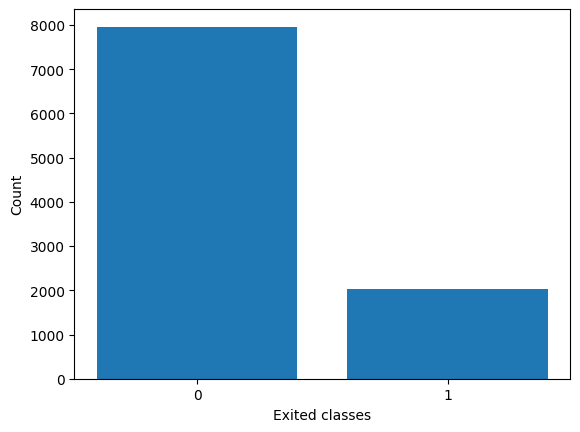

In [26]:
display(df['Exited'].value_counts())

class_counts = df['Exited'].value_counts()

plt.bar(class_counts.index, class_counts.values)
plt.xticks(class_counts.index)
plt.xlabel("Exited classes")
plt.ylabel("Count")
plt.show()

In [27]:
df=df.drop(['RowNumber','CustomerId','Surname'],axis=1)
display(df.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
X=df.drop('Exited',axis=1)
y=df['Exited']
cat_cols=X.select_dtypes(include='object').columns
numeric_cols=X.select_dtypes(exclude='object').columns
display(cat_cols)
display(numeric_cols)

Index(['Geography', 'Gender'], dtype='object')

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary'],
      dtype='object')

<Figure size 640x480 with 0 Axes>

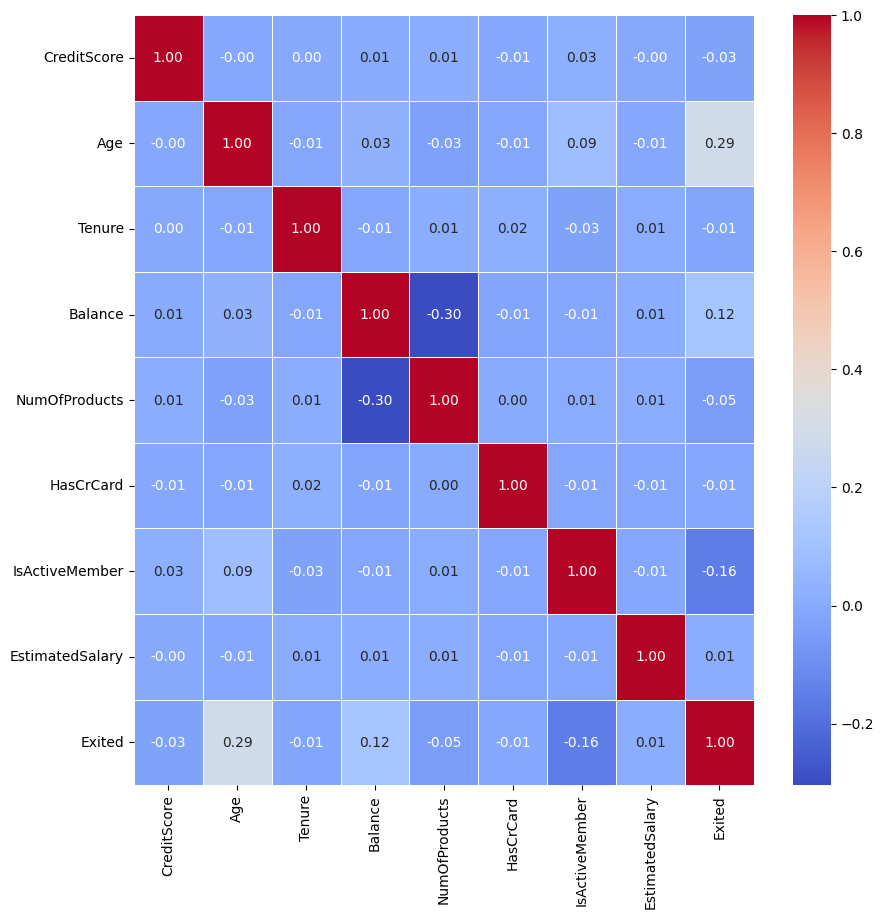

In [29]:
# Draw heatmap, pair plot
corr_matrix = df.select_dtypes(include=['number']).corr()
plt.clf()
plt.figure(figsize=(10, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation values
    cmap='coolwarm',   # color map
    fmt='.2f',         # decimal format
    linewidths=0.5
)
plt.show()

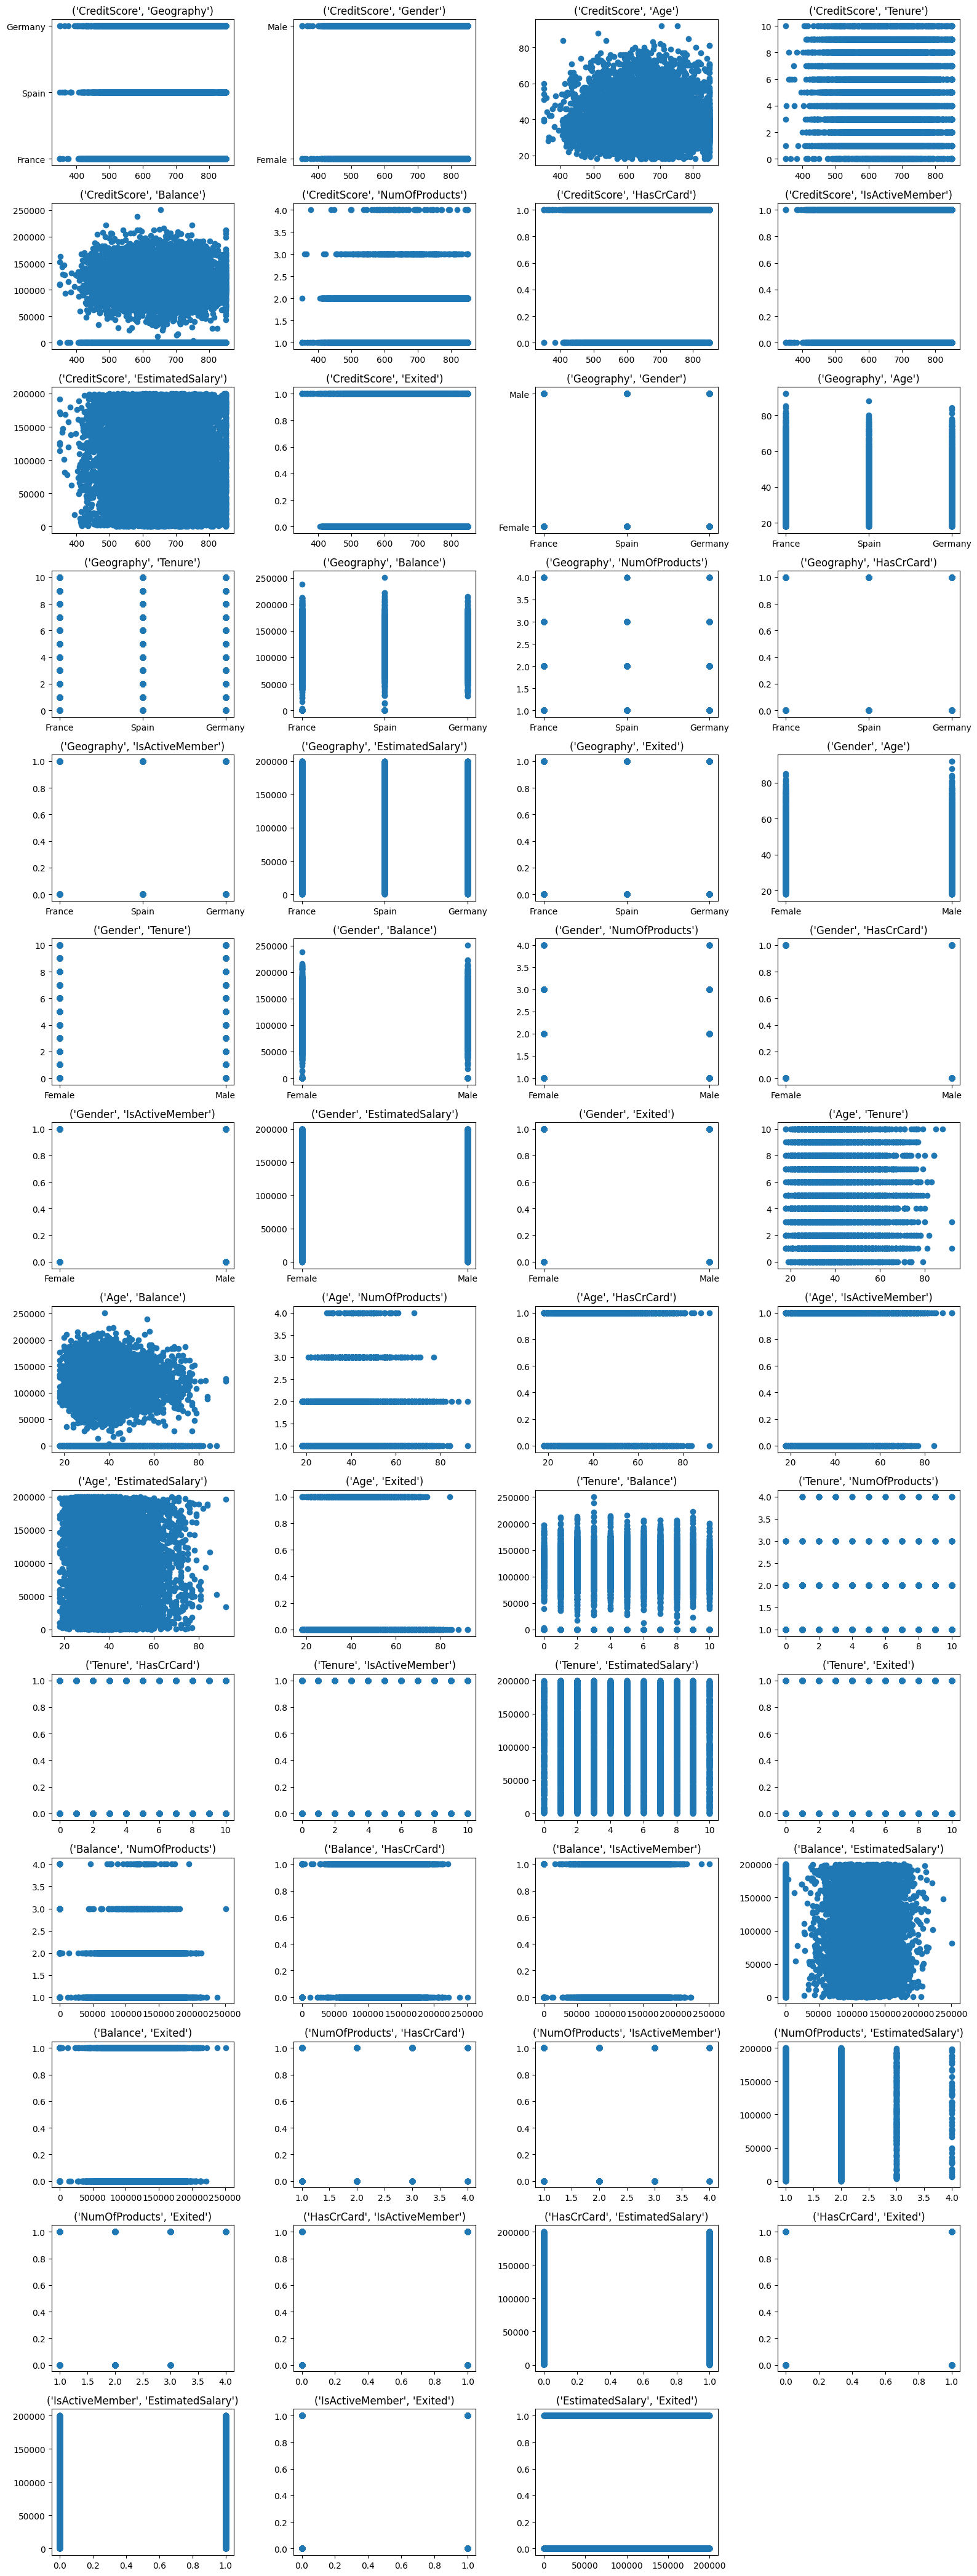

In [30]:
#Drawing graphs between different columns
from itertools import combinations
import math
col_pairs = list(combinations(df.columns, 2))# Creates pairs of two columns.
n_plots = len(col_pairs)
plots_per_row = 4

n_rows = math.ceil(n_plots / plots_per_row)

fig, axes = plt.subplots(
    n_rows,
    plots_per_row,
    figsize=(plots_per_row * 4, n_rows * 3)
)

axes = axes.flatten()

for i, col_pair in enumerate(col_pairs):
    axes[i].scatter(df[col_pair[0]], df[col_pair[1]])
    axes[i].set_title(col_pair)
    

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [31]:
# Calculating VIF. For ANN, we might not need to handle multicollinearity.
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    vif_df = pd.DataFrame()
    vif_df["Feature"] = X.columns
    vif_df["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_df

vif_df=calculate_vif(X[numeric_cols])
display(vif_df)

,Feature,VIF
0,CreditScore,20.542767
1,Age,12.284367
2,Tenure,3.864325
3,Balance,2.624526
4,NumOfProducts,7.702215
5,HasCrCard,3.286163
6,IsActiveMember,2.071745
7,EstimatedSalary,3.885144


In [32]:
# Calculating skewness.For ANN, we might not need to handle skewness.
skewness = X[numeric_cols].skew()
display(skewness)

CreditScore       -0.071607
Age                1.011320
Tenure             0.010991
Balance           -0.141109
NumOfProducts      0.745568
HasCrCard         -0.901812
IsActiveMember    -0.060437
EstimatedSalary    0.002085
dtype: float64

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=7)

In [34]:
X_train.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4858,779,France,Female,41,10,99786.20,1,1,0,86927.53
1733,614,Germany,Male,32,7,99462.80,2,1,1,51117.06
7073,679,France,Male,40,1,0.00,1,1,1,16897.19
9864,742,Germany,Male,33,1,137937.95,1,1,1,51387.10
438,800,France,Female,38,2,168190.33,2,1,0,68052.08


In [35]:
# Scaling numerical columns
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])
display(X_train.head(5))

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4858,1.341735,France,Female,0.194002,1.721841,0.371227,-0.907344,0.646092,-1.032787,-0.222394
1733,-0.367581,Germany,Male,-0.664519,0.686147,0.366061,0.809079,0.646092,0.968254,-0.848388
7073,0.305786,France,Male,0.098611,-1.385240,-1.222902,-0.907344,0.646092,0.968254,-1.446577
9864,0.958434,Germany,Male,-0.569128,-1.385240,0.980718,-0.907344,0.646092,0.968254,-0.843667
438,1.559284,France,Female,-0.092172,-1.040009,1.464014,0.809079,0.646092,-1.032787,-0.552351


In [36]:
# Label encoding:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le

In [37]:
X_train.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
4858,1.341735,0,0,0.194002,1.721841,0.371227,-0.907344,0.646092,-1.032787,-0.222394
1733,-0.367581,1,1,-0.664519,0.686147,0.366061,0.809079,0.646092,0.968254,-0.848388
7073,0.305786,0,1,0.098611,-1.385240,-1.222902,-0.907344,0.646092,0.968254,-1.446577
9864,0.958434,1,1,-0.569128,-1.385240,0.980718,-0.907344,0.646092,0.968254,-0.843667
438,1.559284,0,0,-0.092172,-1.040009,1.464014,0.809079,0.646092,-1.032787,-0.552351


In [38]:
#Performing oversampling
from imblearn.over_sampling  import SMOTE

smotemek = SMOTE(sampling_strategy=.5, random_state=3)
X_train, y_train = smotemek.fit_resample(X_train, y_train)
display(y_train.value_counts())

Exited
0    6370
1    3185
Name: count, dtype: int64

In [121]:
# Model with just input and output layer
from tensorflow.keras.layers import Input
from sklearn.metrics import r2_score

model=keras.Sequential()
model.add(Input(shape=(X_train.shape[1],), name='input_layer'))# Input layer
model.add(Dense(16, activation='relu', name='hidden_layer_1'))
#model.add(Dropout(0.2, name='dropout_layer_1'))  # Dropout layer to prevent overfitting
model.add(Dense(8, activation='relu', name='hidden_layer_2'))
#model.add(Dropout(0.2, name='dropout_layer_2'))
#model.add(Dense(2, activation='relu', name='hidden_layer_3'))
model.add(Dense(1, activation='sigmoid', name='output_layer'))# Output layer

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callback=EarlyStopping(monitor='val_loss', patience=10, min_delta=0.01, verbose=1)
class_weight = { 0: 1.0, 1: 1.06 }

checkpoint = ModelCheckpoint(filepath='bank_churn_best_model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
# history=model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[callback, checkpoint], class_weight=class_weight)
history=model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, callbacks=[checkpoint], class_weight=class_weight)

Epoch 1/50
225/239 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7643 - loss: 0.5394
Epoch 1: val_loss improved from None to 1.09150, saving model to bank_churn_best_model.keras

Epoch 1: finished saving model to bank_churn_best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7923 - loss: 0.4997 - val_accuracy: 0.2580 - val_loss: 1.0915
Epoch 2/50
229/239 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8110 - loss: 0.4397
Epoch 2: val_loss improved from 1.09150 to 1.01903, saving model to bank_churn_best_model.keras

Epoch 2: finished saving model to bank_churn_best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8110 - loss: 0.4473 - val_accuracy: 0.3375 - val_loss: 1.0190
Epoch 3/50
224/239 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8137 - loss: 0.4332
Epoch 3: val_loss improved from 1.01903 to 0.99123, saving model to bank_churn_best_model.keras

Epoch 3: finished saving model to bank_churn_best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

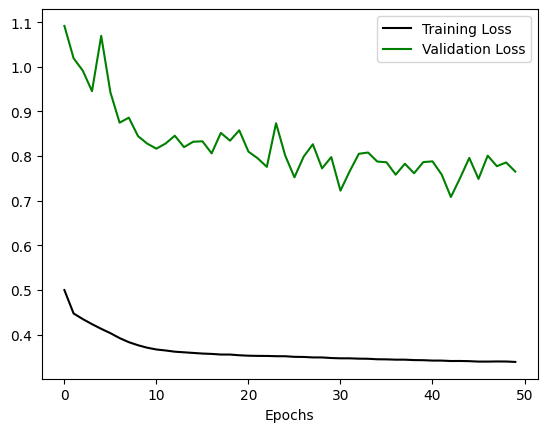

In [122]:
plt.clf()
plt.plot(history.history['loss'], label='Training Loss',color='black')
plt.plot(history.history['val_loss'], label='Validation Loss',color='green')
plt.xlabel('Epochs')
plt.legend()
plt.show()

In [123]:
model=load_model('bank_churn_best_model.keras')
y_pred = model.predict(X_test)
threshold = 0.35
y_pred = (y_pred > threshold).astype(int)  # Convert probabilities to binary predictions
print("Accuracy: test", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:test\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:test\n", classification_report(y_test, y_pred))

y_pred = model.predict(X_train)
y_pred = (y_pred > threshold).astype(int)  # Convert probabilities to binary predictions
print("Accuracy:train", accuracy_score(y_train, y_pred))
print("\nConfusion Matrix:train\n", confusion_matrix(y_train, y_pred))
print("\nClassification Report:train\n", classification_report(y_train, y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: test 0.828

Confusion Matrix:test
 [[1399  194]
 [ 150  257]]

Classification Report:test
               precision    recall  f1-score   support

           0       0.90      0.88      0.89      1593
           1       0.57      0.63      0.60       407

    accuracy                           0.83      2000
   macro avg       0.74      0.75      0.74      2000
weighted avg       0.84      0.83      0.83      2000

299/299 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
Accuracy:train 0.8173731030873888

Confusion Matrix:train
 [[5626  744]
 [1001 2184]]

Classification Report:train
               precision    recall  f1-score   support

           0       0.85      0.88      0.87      6370
           1       0.75      0.69      0.71      3185

    accuracy                           0.82      9555
   macro avg       0.80      0.78      0.79      9555
weighted avg       0.81      0.82      0.82      9555



In [6]:
# c) Use the following Accident detection Dataset link and create an end-to-end project to predict Accident 
# has happened or not.


In [126]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Dropout
from keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from keras.layers import Dense, Conv2D, BatchNormalization, MaxPooling2D, Input, Flatten,\
Dropout

In [127]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory="accident_data/train",
    labels='inferred',
    label_mode='binary',
    class_names=['Non_Accident', 'Accident'],  # order matters
    image_size=(256, 256),
    shuffle=True,
    seed=41,
    batch_size=32
)

validation_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory="accident_data/val",
    labels='inferred',
    label_mode='binary',
    class_names=['Non_Accident', 'Accident'],  # order matters
    image_size=(256, 256),
    shuffle=True,
    seed=41,
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory="accident_data/test",
    labels='inferred',
    label_mode='binary',
    class_names=['Non_Accident', 'Accident'],  # order matters
    image_size=(256, 256),
    shuffle=True,
    seed=41,
    batch_size=32
)

Found 791 files belonging to 2 classes.


Found 98 files belonging to 2 classes.
Found 100 files belonging to 2 classes.


In [128]:
# scale bit values from 0-255 to 0-1
def process(img, label):
    return tf.cast(img / 255, tf.float32), label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)
test_ds = test_ds.map(process)

(256, 256, 3) [1.]


np.float32(1.0)

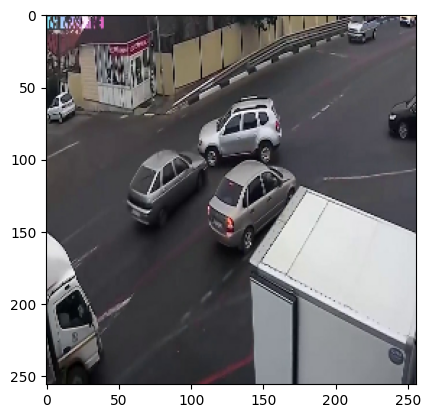

In [129]:
# Just displaying image
ds = validation_ds.unbatch()   # now dataset yields (image, label)

for image, label in ds.skip(10).take(1):
    print(image.numpy().shape, label.numpy())
    plt.imshow(image.numpy())
    display(label.numpy()[0])

In [141]:
# CNN Model
acident_prediction_model = Sequential()
acident_prediction_model.add(Input(shape=(256,256,3), name='input_layer'))
acident_prediction_model.add(Conv2D(32,kernel_size=(3,3), padding='valid',activation='relu', name='conv_1'))
acident_prediction_model.add(BatchNormalization())
acident_prediction_model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid',name='maxpool_1'))

acident_prediction_model.add(Conv2D(64,kernel_size=(3,3), padding='valid',activation='relu', name='conv_2'))
acident_prediction_model.add(BatchNormalization())
acident_prediction_model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid', name='maxpool_2'))

acident_prediction_model.add(Conv2D(128,kernel_size=(3,3), padding='valid',activation='relu', name='conv_3'))
acident_prediction_model.add(BatchNormalization())
acident_prediction_model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid', name='maxpool_3'))

acident_prediction_model.add(Flatten())

acident_prediction_model.add(Dense(128, activation='relu', name='ann_hidden_1'))
acident_prediction_model.add(Dropout(.1))

acident_prediction_model.add(Dense(64, activation='relu', name='ann_hidden_2'))
acident_prediction_model.add(Dropout(.1))

acident_prediction_model.add(Dense(1, activation='sigmoid', name='output_layer'))

print(acident_prediction_model.summary())

Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling2D)        │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling2D)        │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_3 (MaxPooling2D)        │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_1 (Dense)            │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ann_hidden_2 (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

None


In [143]:
acident_prediction_model.compile(optimizer='adam', loss='binary_crossentropy',metrics=['accuracy'])

In [144]:
checkpoint = ModelCheckpoint(filepath='accident_prediction_best_model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
history=acident_prediction_model.fit(train_ds, epochs=30, validation_data=validation_ds, verbose=1, callbacks=[checkpoint])

Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5639 - loss: 10.3186
Epoch 1: val_loss improved from None to 3.61189, saving model to accident_prediction_best_model.keras

Epoch 1: finished saving model to accident_prediction_best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.6018 - loss: 8.5944 - val_accuracy: 0.5306 - val_loss: 3.6119
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6593 - loss: 6.5865
Epoch 2: val_loss did not improve from 3.61189
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.6561 - loss: 6.1583 - val_accuracy: 0.4490 - val_loss: 5.4216
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6451 - loss: 5.1851
Epoch 3: val_loss improved from 3.61189 to 3.12553, saving model to accident_prediction_best_model.keras

Epoch 3: finished saving model to accident_prediction_best_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 79s 3s/step - accuracy: 0.6359 - loss: 6.0508 - val_accuracy: 0.4898 - val_loss: 3.1255
Epoch 4

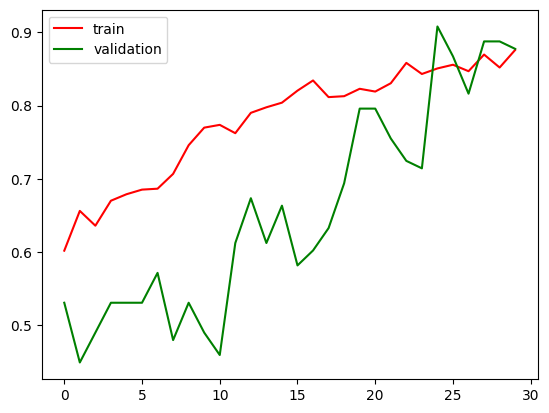

In [145]:
plt.plot(history.history['accuracy'],color='red', label='train')
plt.plot(history.history['val_accuracy'],color='green', label='validation')
plt.legend()
plt.show()

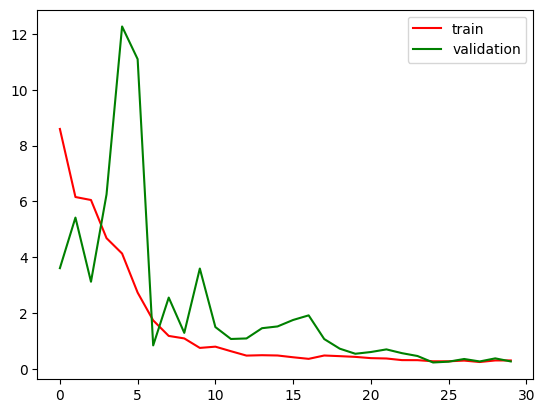

In [146]:
plt.plot(history.history['loss'],color='red', label='train')
plt.plot(history.history['val_loss'],color='green', label='validation')
plt.legend()
plt.show()

In [149]:
# Function to calculate accuracy, confusion matrix and classification report

from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

def print_metrics(X_Y):
    y_true = []
    y_pred = []

    for X_batch, y_batch in validation_ds:
        # Predict on the SAME batch
        y_pred_batch = acident_prediction_model.predict(X_batch, verbose=0)
        y_pred_batch = (y_pred_batch >= 0.5).astype(int).ravel()

        y_pred.extend(y_pred_batch)
        y_true.extend(y_batch.numpy().ravel())
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print(f"Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))


In [150]:
print_metrics(train_ds)

Accuracy: 0.8775510204081632

Confusion Matrix:
 [[47  5]
 [ 7 39]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.90      0.89        52
         1.0       0.89      0.85      0.87        46

    accuracy                           0.88        98
   macro avg       0.88      0.88      0.88        98
weighted avg       0.88      0.88      0.88        98



In [151]:
print_metrics(validation_ds)

Accuracy: 0.8775510204081632

Confusion Matrix:
 [[47  5]
 [ 7 39]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.90      0.89        52
         1.0       0.89      0.85      0.87        46

    accuracy                           0.88        98
   macro avg       0.88      0.88      0.88        98
weighted avg       0.88      0.88      0.88        98



In [152]:
print_metrics(test_ds)

Accuracy: 0.8775510204081632

Confusion Matrix:
 [[47  5]
 [ 7 39]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.87      0.90      0.89        52
         1.0       0.89      0.85      0.87        46

    accuracy                           0.88        98
   macro avg       0.88      0.88      0.88        98
weighted avg       0.88      0.88      0.88        98

